# Infrastructure Logic

This notebook builds AI logic for the Infrastructure module: gate allocation, parking bay occupancy, runway scheduling, baggage belt allocation, GPU health, closure impact, utilization scoring, conflict detection, AI recommendations, and backend-ready dashboard payloads.

## 1. Setup

In [1]:
import random
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1200)

now = datetime(2026, 4, 27, 9, 0)

## 2. Infrastructure Configuration

In [2]:
TERMINALS = ['T1', 'T2', 'T3', 'T4']
GATE_STATUSES = ['available', 'occupied', 'boarding', 'cleaning', 'maintenance', 'closed']
BAY_STATUSES = ['available', 'occupied', 'reserved', 'maintenance', 'closed']
RUNWAY_STATUSES = ['active', 'restricted', 'closed']
GPU_STATUSES = ['active', 'standby', 'fault', 'maintenance']

AIRCRAFT_TYPES = {
    'ATR72': {'size': 'regional', 'gate_type': 'regional', 'bay_type': 'regional', 'gpu_load': 45},
    'A320': {'size': 'narrow_body', 'gate_type': 'narrow_body', 'bay_type': 'standard', 'gpu_load': 72},
    'B737': {'size': 'narrow_body', 'gate_type': 'narrow_body', 'bay_type': 'standard', 'gpu_load': 75},
    'A321': {'size': 'narrow_body', 'gate_type': 'narrow_body', 'bay_type': 'standard', 'gpu_load': 82},
    'B777': {'size': 'wide_body', 'gate_type': 'wide_body', 'bay_type': 'wide_body', 'gpu_load': 92},
    'A350': {'size': 'wide_body', 'gate_type': 'wide_body', 'bay_type': 'wide_body', 'gpu_load': 95},
}

RUNWAYS = {
    '28L/10R': {'length_m': 3900, 'surface': 'Asphalt', 'capacity_per_hour': 38, 'status': 'active'},
    '28R/10L': {'length_m': 3200, 'surface': 'Concrete', 'capacity_per_hour': 32, 'status': 'active'},
    '14/32': {'length_m': 2800, 'surface': 'Asphalt', 'capacity_per_hour': 24, 'status': 'closed'},
}

BAGGAGE_BELTS = [f'B{str(i).zfill(2)}' for i in range(1, 13)]

## 3. Generate Infrastructure Assets

In [3]:
def generate_gates():
    rows = []
    for terminal_index, terminal in enumerate(TERMINALS):
        for gate_index in range(1, 7):
            gate_num = terminal_index * 6 + gate_index
            gate_type = 'wide_body' if gate_num in [4, 8, 12, 16, 20, 24] else 'regional' if gate_num in [5, 11, 17, 23] else 'narrow_body'
            status = random.choices(GATE_STATUSES, weights=[28, 33, 14, 8, 9, 8])[0]
            rows.append({
                'gate_id': f'{chr(64 + terminal_index + 1)}{gate_index}',
                'terminal': terminal,
                'gate_type': gate_type,
                'status': status,
                'jet_bridge': gate_type != 'regional',
                'x': 12 + terminal_index * 25,
                'y': 16 + gate_index * 12,
            })
    return pd.DataFrame(rows)


def generate_parking_bays(n=30):
    rows = []
    for i in range(1, n + 1):
        bay_type = 'wide_body' if i % 7 == 0 else 'regional' if i % 6 == 0 else 'standard'
        status = random.choices(BAY_STATUSES, weights=[32, 42, 9, 12, 5])[0]
        rows.append({
            'bay_id': f'P{str(i).zfill(2)}',
            'bay_type': bay_type,
            'terminal_zone': random.choice(TERMINALS),
            'status': status,
            'occupied_since': now - timedelta(minutes=random.randint(20, 260)) if status == 'occupied' else pd.NaT,
        })
    return pd.DataFrame(rows)


def generate_gpus(n=20):
    rows = []
    for i in range(1, n + 1):
        status = random.choices(GPU_STATUSES, weights=[56, 22, 10, 12])[0]
        health = int(np.clip(np.random.normal(86 if status != 'fault' else 28, 12), 5, 100))
        load = random.randint(55, 98) if status == 'active' else 0
        rows.append({
            'gpu_id': f'GPU-{str(i).zfill(2)}',
            'gate_id': random.choice([f'{t}{g}' for t in ['A', 'B', 'C', 'D'] for g in range(1, 7)] + ['STANDBY']),
            'status': status,
            'load_pct': load,
            'health_pct': health,
            'voltage': '115V' if status == 'active' else '0V' if status == 'standby' else 'FAULT',
        })
    return pd.DataFrame(rows)


gates_df = generate_gates()
bays_df = generate_parking_bays()
gpus_df = generate_gpus()
runways_df = pd.DataFrame([{'runway_id': k, **v} for k, v in RUNWAYS.items()])

display(gates_df.head())
display(bays_df.head())
gpus_df.head()

,gate_id,terminal,gate_type,status,jet_bridge,x,y
0,A1,T1,narrow_body,boarding,True,12,28
1,A2,T1,narrow_body,available,True,12,40
2,A3,T1,narrow_body,available,True,12,52
3,A4,T1,wide_body,available,True,12,64
4,A5,T1,regional,boarding,False,12,76


,bay_id,bay_type,terminal_zone,status,occupied_since
0,P01,standard,T3,closed,NaT
1,P02,standard,T4,available,NaT
2,P03,standard,T3,available,NaT
3,P04,standard,T1,occupied,2026-04-27 05:34:00
4,P05,standard,T1,occupied,2026-04-27 04:44:00


,gpu_id,gate_id,status,load_pct,health_pct,voltage
0,GPU-01,A6,active,95,91,115V
1,GPU-02,C2,fault,0,26,FAULT
2,GPU-03,C1,standby,0,93,0V
3,GPU-04,C5,active,84,100,115V
4,GPU-05,A1,active,90,83,115V


## 4. Generate Flight Infrastructure Demand

In [4]:
def generate_flight_demand(n=42):
    rows = []
    priority_rank_map = {'Normal': 0, 'VIP': 1, 'Connection Critical': 2, 'Emergency': 3}

    for i in range(n):
        aircraft = random.choice(list(AIRCRAFT_TYPES.keys()))
        profile = AIRCRAFT_TYPES[aircraft]
        arrival = now + timedelta(minutes=random.randint(-80, 220))
        turnaround = random.randint(38, 120)
        departure = arrival + timedelta(minutes=turnaround)
        movement_type = random.choice(['arrival', 'departure'])
        movement_time = arrival if movement_type == 'arrival' else departure
        priority = random.choices(['Normal', 'VIP', 'Emergency', 'Connection Critical'], weights=[75, 7, 3, 15])[0]

        rows.append({
            'flight_id': f'{random.choice(["AI", "6E", "SG", "UK", "QP"])}{random.randint(100, 999)}',
            'aircraft_type': aircraft,
            'aircraft_size': profile['size'],
            'required_gate_type': profile['gate_type'],
            'required_bay_type': profile['bay_type'],
            'gpu_load_required': profile['gpu_load'],
            'arrival_time': arrival,
            'departure_time': departure,
            'movement_time': movement_time,
            'movement_type': movement_type,
            'priority': priority,
            'priority_rank': priority_rank_map[priority],
            'passengers': random.randint(55, 410),
        })

    flights_df = pd.DataFrame(rows).sort_values('arrival_time').reset_index(drop=True)
    flights_df['minutes_to_movement'] = ((flights_df['movement_time'] - now).dt.total_seconds() / 60).round(1)
    flights_df['ops_priority_score'] = (
        flights_df['priority_rank'] * 14 +
        np.maximum(0, 40 - flights_df['minutes_to_movement']) * 0.8 +
        flights_df['passengers'] / 45
    ).round(1)
    return flights_df.sort_values(['ops_priority_score', 'arrival_time'], ascending=[False, True]).reset_index(drop=True)


flights_df = generate_flight_demand()
flights_df.head(10)


,flight_id,aircraft_type,aircraft_size,required_gate_type,required_bay_type,gpu_load_required,arrival_time,departure_time,movement_time,movement_type,priority,priority_rank,passengers,minutes_to_movement,ops_priority_score
0,QP665,ATR72,regional,regional,regional,45,2026-04-27 08:18:00,2026-04-27 09:15:00,2026-04-27 08:18:00,arrival,Emergency,3,130,-42.0,110.5
1,QP678,B777,wide_body,wide_body,wide_body,92,2026-04-27 08:00:00,2026-04-27 09:57:00,2026-04-27 08:00:00,arrival,Normal,0,322,-60.0,87.2
2,AI103,B737,narrow_body,narrow_body,standard,75,2026-04-27 08:06:00,2026-04-27 08:55:00,2026-04-27 08:55:00,departure,Emergency,3,225,-5.0,83.0
3,UK935,A320,narrow_body,narrow_body,standard,72,2026-04-27 08:09:00,2026-04-27 09:17:00,2026-04-27 08:09:00,arrival,Normal,0,90,-51.0,74.8
4,QP259,ATR72,regional,regional,regional,45,2026-04-27 08:48:00,2026-04-27 09:59:00,2026-04-27 08:48:00,arrival,Connection Critical,2,194,-12.0,73.9
5,SG902,ATR72,regional,regional,regional,45,2026-04-27 09:04:00,2026-04-27 10:30:00,2026-04-27 09:04:00,arrival,Connection Critical,2,287,4.0,63.2
6,AI709,B777,wide_body,wide_body,wide_body,92,2026-04-27 09:00:00,2026-04-27 09:45:00,2026-04-27 09:00:00,arrival,Connection Critical,2,89,0.0,62.0
7,6E371,B777,wide_body,wide_body,wide_body,92,2026-04-27 08:44:00,2026-04-27 09:38:00,2026-04-27 09:38:00,departure,Connection Critical,2,325,38.0,36.8
8,QP352,A350,wide_body,wide_body,wide_body,95,2026-04-27 09:40:00,2026-04-27 11:09:00,2026-04-27 09:40:00,arrival,Connection Critical,2,351,40.0,35.8
9,AI109,A350,wide_body,wide_body,wide_body,95,2026-04-27 10:13:00,2026-04-27 11:49:00,2026-04-27 11:49:00,departure,Connection Critical,2,289,169.0,34.4


## 5. Allocation Engine

In [5]:
def overlaps(start_a, end_a, start_b, end_b, buffer_minutes=12):
    return start_a < end_b + timedelta(minutes=buffer_minutes) and start_b < end_a + timedelta(minutes=buffer_minutes)


def compatible_gate_candidates(gates, required_type):
    available = gates[~gates['status'].isin(['maintenance', 'closed'])].copy()
    if required_type == 'wide_body':
        return available[available['gate_type'] == 'wide_body']['gate_id'].tolist()
    if required_type == 'regional':
        return available[available['gate_type'].isin(['regional', 'narrow_body'])]['gate_id'].tolist()
    return available[available['gate_type'].isin(['narrow_body', 'wide_body'])]['gate_id'].tolist()


def compatible_bay_candidates(bays, required_type):
    available = bays[~bays['status'].isin(['maintenance', 'closed'])].copy()
    if required_type == 'wide_body':
        return available[available['bay_type'] == 'wide_body']['bay_id'].tolist()
    if required_type == 'regional':
        return available[available['bay_type'].isin(['regional', 'standard'])]['bay_id'].tolist()
    return available[available['bay_type'].isin(['standard', 'wide_body'])]['bay_id'].tolist()


def allocate_infrastructure(flights, gates, bays, runways, gpus):
    gate_schedule = {gate: [] for gate in gates['gate_id']}
    bay_schedule = {bay: [] for bay in bays['bay_id']}
    runway_schedule = {rwy: [] for rwy in runways['runway_id']}
    gpu_schedule = {gpu: [] for gpu in gpus['gpu_id']}
    active_gpus = gpus[gpus['status'].isin(['active', 'standby']) & (gpus['health_pct'] >= 55)].copy()
    active_runways = runways[runways['status'] == 'active'].copy()
    assignments = []

    ordered_flights = flights.sort_values(
        ['ops_priority_score', 'minutes_to_movement', 'arrival_time'],
        ascending=[False, True, True],
    )

    for _, flight in ordered_flights.iterrows():
        service_start = flight['arrival_time'] - timedelta(minutes=10)
        service_end = flight['departure_time'] + timedelta(minutes=10)

        feasible_gates = [
            gate for gate in compatible_gate_candidates(gates, flight['required_gate_type'])
            if not any(overlaps(service_start, service_end, s, e) for s, e in gate_schedule[gate])
        ]
        gate_id = 'REMOTE'
        if feasible_gates:
            gate_id = min(feasible_gates, key=lambda gate: (len(gate_schedule[gate]), gate))
            gate_schedule[gate_id].append((service_start, service_end))

        feasible_bays = [
            bay for bay in compatible_bay_candidates(bays, flight['required_bay_type'])
            if not any(overlaps(service_start, service_end, s, e) for s, e in bay_schedule[bay])
        ]
        bay_id = 'WAITLIST'
        if feasible_bays:
            bay_id = min(feasible_bays, key=lambda bay: (len(bay_schedule[bay]), bay))
            bay_schedule[bay_id].append((service_start, service_end))

        movement_time = flight['movement_time']
        if len(active_runways):
            runway_id = min(
                active_runways['runway_id'],
                key=lambda runway: (
                    sum(abs((movement_time - ts).total_seconds()) < 15 * 60 for ts in runway_schedule[runway]),
                    len(runway_schedule[runway]),
                    runway,
                ),
            )
            runway_schedule[runway_id].append(movement_time)
        else:
            runway_id = 'NO_ACTIVE_RUNWAY'

        feasible_gpus = []
        for _, gpu in active_gpus.sort_values(['health_pct', 'load_pct'], ascending=[False, True]).iterrows():
            if not any(overlaps(service_start, service_end, s, e, buffer_minutes=5) for s, e in gpu_schedule[gpu['gpu_id']]):
                feasible_gpus.append(gpu['gpu_id'])
        gpu_id = 'GPU-WAITLIST'
        if feasible_gpus:
            gpu_id = min(feasible_gpus, key=lambda gpu: (len(gpu_schedule[gpu]), gpu))
            gpu_schedule[gpu_id].append((service_start, service_end))

        assignments.append({
            'flight_id': flight['flight_id'],
            'assigned_gate': gate_id,
            'assigned_bay': bay_id,
            'assigned_runway': runway_id,
            'assigned_gpu': gpu_id,
        })

    return flights.merge(pd.DataFrame(assignments), on='flight_id', how='left')


allocations_df = allocate_infrastructure(flights_df, gates_df, bays_df, runways_df, gpus_df)
allocations_df[['flight_id', 'aircraft_type', 'assigned_gate', 'assigned_bay', 'assigned_runway', 'assigned_gpu']].head(15)


,flight_id,aircraft_type,assigned_gate,assigned_bay,assigned_runway,assigned_gpu
0,QP665,ATR72,A1,P02,28L/10R,GPU-01
1,QP678,B777,A4,P07,28R/10L,GPU-03
2,AI103,B737,A2,P03,28L/10R,GPU-04
3,UK935,A320,A3,P04,28R/10L,GPU-05
4,QP259,ATR72,A5,P05,28R/10L,GPU-06
5,SG902,ATR72,A6,P06,28R/10L,GPU-07
6,AI709,B777,B2,P14,28L/10R,GPU-08
7,6E371,B777,B6,P21,28L/10R,GPU-09
8,QP352,A350,C4,WAITLIST,28R/10L,GPU-10
9,AI109,A350,D2,P21,28L/10R,GPU-11


## 6. Utilization and Closure Impact

In [6]:
def build_utilization_tables(gates, bays, runways, gpus, allocations):
    gate_total = len(gates)
    gate_usable = len(gates[~gates['status'].isin(['closed', 'maintenance'])])
    gate_assigned = int((allocations['assigned_gate'] != 'REMOTE').sum())
    bay_total = len(bays)
    bay_usable = len(bays[~bays['status'].isin(['closed', 'maintenance'])])
    bay_assigned = int((allocations['assigned_bay'] != 'WAITLIST').sum())
    gpu_usable = len(gpus[gpus['status'].isin(['active', 'standby']) & (gpus['health_pct'] >= 55)])
    gpu_assigned = int((allocations['assigned_gpu'] != 'GPU-WAITLIST').sum())

    asset_summary = pd.DataFrame([
        {'asset_type': 'Gates', 'total': gate_total, 'usable': gate_usable, 'assigned': gate_assigned, 'waitlisted': int((allocations['assigned_gate'] == 'REMOTE').sum())},
        {'asset_type': 'Parking Bays', 'total': bay_total, 'usable': bay_usable, 'assigned': bay_assigned, 'waitlisted': int((allocations['assigned_bay'] == 'WAITLIST').sum())},
        {'asset_type': 'GPUs', 'total': len(gpus), 'usable': gpu_usable, 'assigned': gpu_assigned, 'waitlisted': int((allocations['assigned_gpu'] == 'GPU-WAITLIST').sum())},
    ])
    asset_summary['assignment_rate_pct'] = (asset_summary['assigned'] / len(allocations) * 100).round(1)
    asset_summary['usable_utilization_pct'] = (asset_summary['assigned'] / asset_summary['usable'].replace(0, 1) * 100).round(1)
    asset_summary['status'] = np.where(asset_summary['waitlisted'] > 0, 'shortage', np.where(asset_summary['usable_utilization_pct'] >= 85, 'tight', 'ok'))

    runway_hourly = allocations.assign(hour=allocations['movement_time'].dt.floor('h')).groupby(['assigned_runway', 'hour']).size().reset_index(name='movements')
    runway_capacity = runways[['runway_id', 'capacity_per_hour', 'status']]
    runway_pressure = runway_hourly.merge(runway_capacity, left_on='assigned_runway', right_on='runway_id', how='left')
    runway_pressure['utilization_pct'] = (runway_pressure['movements'] / runway_pressure['capacity_per_hour'].replace(0, 1) * 100).round(1)

    closure_impact = pd.DataFrame([{
        'closed_runways': int((runways['status'] == 'closed').sum()),
        'closed_gates': int(gates['status'].isin(['closed', 'maintenance']).sum()),
        'closed_bays': int(bays['status'].isin(['closed', 'maintenance']).sum()),
        'fault_gpus': int(gpus['status'].isin(['fault', 'maintenance']).sum()),
    }])

    return asset_summary, runway_pressure, closure_impact


asset_summary_df, runway_pressure_df, closure_impact_df = build_utilization_tables(gates_df, bays_df, runways_df, gpus_df, allocations_df)
display(asset_summary_df)
display(runway_pressure_df.head(10))
closure_impact_df

,asset_type,total,usable,assigned,waitlisted,assignment_rate_pct,usable_utilization_pct,status
0,Gates,24,23,39,3,92.9,169.6,shortage
1,Parking Bays,30,25,33,9,78.6,132.0,shortage
2,GPUs,20,15,37,5,88.1,246.7,shortage


,assigned_runway,hour,movements,runway_id,capacity_per_hour,status,utilization_pct
0,28L/10R,2026-04-27 08:00:00,2,28L/10R,38,active,5.3
1,28L/10R,2026-04-27 09:00:00,5,28L/10R,38,active,13.2
2,28L/10R,2026-04-27 10:00:00,5,28L/10R,38,active,13.2
3,28L/10R,2026-04-27 11:00:00,3,28L/10R,38,active,7.9
4,28L/10R,2026-04-27 12:00:00,2,28L/10R,38,active,5.3
5,28L/10R,2026-04-27 13:00:00,4,28L/10R,38,active,10.5
6,28R/10L,2026-04-27 08:00:00,3,28R/10L,32,active,9.4
7,28R/10L,2026-04-27 09:00:00,5,28R/10L,32,active,15.6
8,28R/10L,2026-04-27 10:00:00,5,28R/10L,32,active,15.6
9,28R/10L,2026-04-27 11:00:00,2,28R/10L,32,active,6.2


,closed_runways,closed_gates,closed_bays,fault_gpus
0,1,1,5,5


## 7. Conflict Detection

In [7]:
def detect_infrastructure_conflicts(allocations, gates, bays, runways, gpus, runway_pressure):
    conflicts = []

    for _, row in allocations[allocations['assigned_gate'] == 'REMOTE'].iterrows():
        conflicts.append({'type': 'gate_waitlist', 'asset': 'GATE', 'flight_id': row['flight_id'], 'severity': 'High', 'message': f"No compatible gate available for {row['flight_id']}."})

    for _, row in allocations[allocations['assigned_bay'] == 'WAITLIST'].iterrows():
        conflicts.append({'type': 'bay_waitlist', 'asset': 'BAY', 'flight_id': row['flight_id'], 'severity': 'High', 'message': f"No parking bay available for {row['flight_id']}."})

    for _, row in allocations[allocations['assigned_gpu'] == 'GPU-WAITLIST'].iterrows():
        conflicts.append({'type': 'gpu_waitlist', 'asset': 'GPU', 'flight_id': row['flight_id'], 'severity': 'Medium', 'message': f"GPU unavailable for {row['flight_id']}."})

    overloaded_runways = runway_pressure[runway_pressure['utilization_pct'] >= 90]
    for _, row in overloaded_runways.iterrows():
        conflicts.append({'type': 'runway_pressure', 'asset': row['assigned_runway'], 'flight_id': 'SYSTEM', 'severity': 'Medium', 'message': f"{row['assigned_runway']} reaches {row['utilization_pct']}% in hour {row['hour'].strftime('%H:%M')}."})

    for _, gpu in gpus[(gpus['status'] == 'fault') | (gpus['health_pct'] < 45)].iterrows():
        conflicts.append({'type': 'gpu_fault', 'asset': gpu['gpu_id'], 'flight_id': 'SYSTEM', 'severity': 'High', 'message': f"{gpu['gpu_id']} health is {gpu['health_pct']}%."})

    closed_runways = runways[runways['status'] == 'closed']
    for _, runway in closed_runways.iterrows():
        conflicts.append({'type': 'runway_closed', 'asset': runway['runway_id'], 'flight_id': 'SYSTEM', 'severity': 'Medium', 'message': f"Runway {runway['runway_id']} is closed; capacity reduced."})

    return pd.DataFrame(conflicts)


conflicts_df = detect_infrastructure_conflicts(allocations_df, gates_df, bays_df, runways_df, gpus_df, runway_pressure_df)
conflicts_df.head(20)

,type,asset,flight_id,severity,message
0,gate_waitlist,GATE,AI491,High,No compatible gate available for AI491.
1,gate_waitlist,GATE,AI891,High,No compatible gate available for AI891.
2,gate_waitlist,GATE,UK793,High,No compatible gate available for UK793.
3,bay_waitlist,BAY,QP352,High,No parking bay available for QP352.
4,bay_waitlist,BAY,AI354,High,No parking bay available for AI354.
5,bay_waitlist,BAY,UK735,High,No parking bay available for UK735.
6,bay_waitlist,BAY,AI491,High,No parking bay available for AI491.
7,bay_waitlist,BAY,QP406,High,No parking bay available for QP406.
8,bay_waitlist,BAY,AI780,High,No parking bay available for AI780.
9,bay_waitlist,BAY,AI891,High,No parking bay available for AI891.


## 8. AI Recommendations

In [8]:
def build_recommendations(asset_summary, closure_impact, conflicts, allocations):
    recommendations = []

    for _, row in asset_summary[asset_summary['status'] != 'ok'].iterrows():
        recommendations.append({
            'priority_rank': 1 if row['status'] == 'shortage' else 2,
            'type': 'capacity_action',
            'asset': row['asset_type'],
            'severity': 'High' if row['status'] == 'shortage' else 'Medium',
            'message': f"{row['asset_type']} status is {row['status']}; waitlisted {row['waitlisted']}, utilization {row['usable_utilization_pct']}%.",
            'recommendation': 'Open remote stand plan and rebalance assignments.' if row['status'] == 'shortage' else 'Keep standby assets ready for next wave.',
        })

    for _, conflict in conflicts.iterrows():
        recommendation = {
            'gate_waitlist': 'Move low-priority aircraft to remote stand and free nearest compatible gate.',
            'bay_waitlist': 'Use reserve bay or pre-clear long-stay aircraft.',
            'gpu_waitlist': 'Dispatch mobile GPU or rotate standby units to high-priority flights.',
            'runway_pressure': 'Shift departures to alternate active runway and adjust pushback sequence.',
            'gpu_fault': 'Isolate faulty GPU and trigger immediate maintenance work order.',
            'runway_closed': 'Recompute runway schedule and increase taxi buffer for affected flights.',
        }.get(conflict['type'], 'Review infrastructure allocation.')
        recommendations.append({
            'priority_rank': 1 if conflict['severity'] == 'High' else 2,
            'type': conflict['type'],
            'asset': conflict['asset'],
            'severity': conflict['severity'],
            'message': conflict['message'],
            'recommendation': recommendation,
        })

    remote_count = int((allocations['assigned_gate'] == 'REMOTE').sum())
    if remote_count:
        recommendations.append({
            'priority_rank': 1,
            'type': 'passenger_experience',
            'asset': 'REMOTE_STANDS',
            'severity': 'High',
            'message': f"{remote_count} flights routed to remote gates.",
            'recommendation': 'Prepare buses, update passenger notifications, and prioritize families/special assistance.',
        })

    return pd.DataFrame(recommendations).sort_values(['priority_rank', 'severity']).reset_index(drop=True)


recommendations_df = build_recommendations(asset_summary_df, closure_impact_df, conflicts_df, allocations_df)
recommendations_df.head(20)

,priority_rank,type,asset,severity,message,recommendation
0,1,capacity_action,Gates,High,"Gates status is shortage; waitlisted 3, utiliz...",Open remote stand plan and rebalance assignments.
1,1,capacity_action,Parking Bays,High,"Parking Bays status is shortage; waitlisted 9,...",Open remote stand plan and rebalance assignments.
2,1,capacity_action,GPUs,High,"GPUs status is shortage; waitlisted 5, utiliza...",Open remote stand plan and rebalance assignments.
3,1,gate_waitlist,GATE,High,No compatible gate available for AI491.,Move low-priority aircraft to remote stand and...
4,1,gate_waitlist,GATE,High,No compatible gate available for AI891.,Move low-priority aircraft to remote stand and...
5,1,gate_waitlist,GATE,High,No compatible gate available for UK793.,Move low-priority aircraft to remote stand and...
6,1,bay_waitlist,BAY,High,No parking bay available for QP352.,Use reserve bay or pre-clear long-stay aircraft.
7,1,bay_waitlist,BAY,High,No parking bay available for AI354.,Use reserve bay or pre-clear long-stay aircraft.
8,1,bay_waitlist,BAY,High,No parking bay available for UK735.,Use reserve bay or pre-clear long-stay aircraft.
9,1,bay_waitlist,BAY,High,No parking bay available for AI491.,Use reserve bay or pre-clear long-stay aircraft.


## 9. Infrastructure KPI Snapshot

In [9]:
def build_kpis(gates, bays, runways, gpus, allocations, asset_summary, conflicts, recommendations):
    gate_assignment_rate = (allocations['assigned_gate'] != 'REMOTE').mean() * 100
    bay_assignment_rate = (allocations['assigned_bay'] != 'WAITLIST').mean() * 100
    gpu_assignment_rate = (allocations['assigned_gpu'] != 'GPU-WAITLIST').mean() * 100
    active_runway_pct = (runways['status'] == 'active').mean() * 100
    avg_gpu_health = gpus['health_pct'].mean()
    critical_conflicts = int((recommendations['priority_rank'] == 1).sum()) if len(recommendations) else 0
    utilization_penalty = min(asset_summary['usable_utilization_pct'].clip(upper=150).mean() * 0.12, 18)
    score = 0.24 * gate_assignment_rate + 0.20 * bay_assignment_rate + 0.18 * gpu_assignment_rate + 0.18 * active_runway_pct + 0.20 * avg_gpu_health
    score = score - min(len(conflicts) * 1.5, 22) - utilization_penalty

    return pd.DataFrame([{
        'total_gates': len(gates),
        'usable_gates': int((~gates['status'].isin(['closed', 'maintenance'])).sum()),
        'available_gates': int((gates['status'] == 'available').sum()),
        'total_bays': len(bays),
        'available_bays': int((bays['status'] == 'available').sum()),
        'active_runways': int((runways['status'] == 'active').sum()),
        'fault_gpus': int(gpus['status'].isin(['fault', 'maintenance']).sum()),
        'avg_gpu_health_pct': round(avg_gpu_health, 1),
        'gate_assignment_rate_pct': round(gate_assignment_rate, 1),
        'bay_assignment_rate_pct': round(bay_assignment_rate, 1),
        'gpu_assignment_rate_pct': round(gpu_assignment_rate, 1),
        'open_conflicts': len(conflicts),
        'critical_actions': critical_conflicts,
        'infrastructure_operation_score': round(float(np.clip(score, 0, 100)), 1),
    }])


kpi_df = build_kpis(gates_df, bays_df, runways_df, gpus_df, allocations_df, asset_summary_df, conflicts_df, recommendations_df)
kpi_df

,total_gates,usable_gates,available_gates,total_bays,available_bays,active_runways,fault_gpus,avg_gpu_health_pct,gate_assignment_rate_pct,bay_assignment_rate_pct,gpu_assignment_rate_pct,open_conflicts,critical_actions,infrastructure_operation_score
0,24,23,11,30,7,2,5,80.2,92.9,78.6,88.1,19,17,42.6


## 10. Infrastructure Visuals

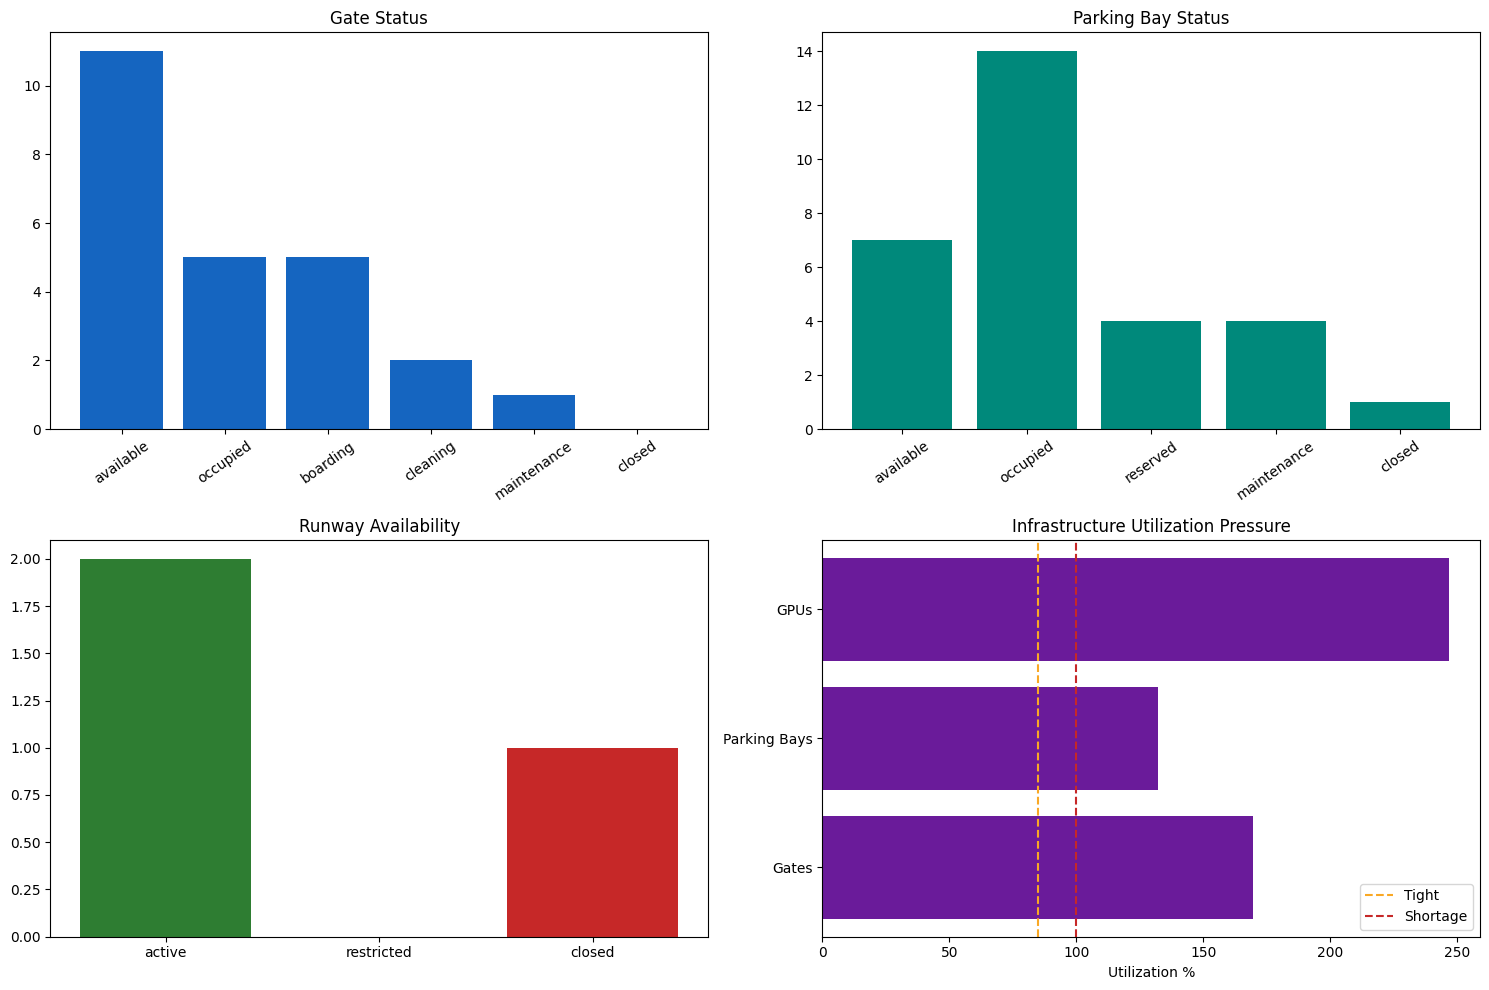

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

gate_status = gates_df['status'].value_counts().reindex(GATE_STATUSES, fill_value=0)
axes[0, 0].bar(gate_status.index, gate_status.values, color='#1565c0')
axes[0, 0].set_title('Gate Status')
axes[0, 0].tick_params(axis='x', rotation=35)

bay_status = bays_df['status'].value_counts().reindex(BAY_STATUSES, fill_value=0)
axes[0, 1].bar(bay_status.index, bay_status.values, color='#00897b')
axes[0, 1].set_title('Parking Bay Status')
axes[0, 1].tick_params(axis='x', rotation=35)

runway_status = runways_df['status'].value_counts().reindex(RUNWAY_STATUSES, fill_value=0)
axes[1, 0].bar(runway_status.index, runway_status.values, color=['#2e7d32', '#f9a825', '#c62828'])
axes[1, 0].set_title('Runway Availability')

axes[1, 1].barh(asset_summary_df['asset_type'], asset_summary_df['usable_utilization_pct'], color='#6a1b9a')
axes[1, 1].axvline(85, color='#f9a825', linestyle='--', label='Tight')
axes[1, 1].axvline(100, color='#c62828', linestyle='--', label='Shortage')
axes[1, 1].set_title('Infrastructure Utilization Pressure')
axes[1, 1].set_xlabel('Utilization %')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 11. Backend-Ready Payload

In [11]:
def build_payload(gates, bays, runways, gpus, allocations, asset_summary, runway_pressure, closure_impact, conflicts, recommendations, kpis):
    return {
        'generated_at': now.isoformat(),
        'kpis': kpis.iloc[0].to_dict(),
        'gates': gates.to_dict(orient='records'),
        'parking_bays': bays.assign(occupied_since=lambda df: df['occupied_since'].astype(str)).to_dict(orient='records'),
        'runways': runways.to_dict(orient='records'),
        'gpus': gpus.to_dict(orient='records'),
        'allocations': allocations.head(50).assign(
            arrival_time=lambda df: df['arrival_time'].astype(str),
            departure_time=lambda df: df['departure_time'].astype(str),
            movement_time=lambda df: df['movement_time'].astype(str),
        ).to_dict(orient='records'),
        'asset_summary': asset_summary.to_dict(orient='records'),
        'runway_pressure': runway_pressure.assign(hour=lambda df: df['hour'].astype(str)).to_dict(orient='records'),
        'closure_impact': closure_impact.iloc[0].to_dict(),
        'conflicts': conflicts.to_dict(orient='records') if not conflicts.empty else [],
        'recommendations': recommendations.head(20).to_dict(orient='records'),
    }


payload = build_payload(gates_df, bays_df, runways_df, gpus_df, allocations_df, asset_summary_df, runway_pressure_df, closure_impact_df, conflicts_df, recommendations_df, kpi_df)
payload

{'generated_at': '2026-04-27T09:00:00',
 'kpis': {'total_gates': 24.0,
  'usable_gates': 23.0,
  'available_gates': 11.0,
  'total_bays': 30.0,
  'available_bays': 7.0,
  'active_runways': 2.0,
  'fault_gpus': 5.0,
  'avg_gpu_health_pct': 80.2,
  'gate_assignment_rate_pct': 92.9,
  'bay_assignment_rate_pct': 78.6,
  'gpu_assignment_rate_pct': 88.1,
  'open_conflicts': 19.0,
  'critical_actions': 17.0,
  'infrastructure_operation_score': 42.6},
 'gates': [{'gate_id': 'A1',
   'terminal': 'T1',
   'gate_type': 'narrow_body',
   'status': 'boarding',
   'jet_bridge': True,
   'x': 12,
   'y': 28},
  {'gate_id': 'A2',
   'terminal': 'T1',
   'gate_type': 'narrow_body',
   'status': 'available',
   'jet_bridge': True,
   'x': 12,
   'y': 40},
  {'gate_id': 'A3',
   'terminal': 'T1',
   'gate_type': 'narrow_body',
   'status': 'available',
   'jet_bridge': True,
   'x': 12,
   'y': 52},
  {'gate_id': 'A4',
   'terminal': 'T1',
   'gate_type': 'wide_body',
   'status': 'available',
   'jet_br

In [12]:
print('INFRASTRUCTURE SUMMARY')
print('======================')
print(f"Usable gates: {payload['kpis']['usable_gates']} / {payload['kpis']['total_gates']}")
print(f"Available bays: {payload['kpis']['available_bays']} / {payload['kpis']['total_bays']}")
print(f"Active runways: {payload['kpis']['active_runways']}")
print(f"Fault/maintenance GPUs: {payload['kpis']['fault_gpus']}")
print(f"Open conflicts: {payload['kpis']['open_conflicts']}")
print(f"Infrastructure Operation Score: {payload['kpis']['infrastructure_operation_score']}")
print('\nTop infrastructure recommendations:')
for item in payload['recommendations'][:5]:
    print(f"- [{item['type']}] {item['message']} {item['recommendation']}")

INFRASTRUCTURE SUMMARY
Usable gates: 23.0 / 24.0
Available bays: 7.0 / 30.0
Active runways: 2.0
Fault/maintenance GPUs: 5.0
Open conflicts: 19.0
Infrastructure Operation Score: 42.6

Top infrastructure recommendations:
- [capacity_action] Gates status is shortage; waitlisted 3, utilization 169.6%. Open remote stand plan and rebalance assignments.
- [capacity_action] Parking Bays status is shortage; waitlisted 9, utilization 132.0%. Open remote stand plan and rebalance assignments.
- [capacity_action] GPUs status is shortage; waitlisted 5, utilization 246.7%. Open remote stand plan and rebalance assignments.
- [gate_waitlist] No compatible gate available for AI491. Move low-priority aircraft to remote stand and free nearest compatible gate.
- [gate_waitlist] No compatible gate available for AI891. Move low-priority aircraft to remote stand and free nearest compatible gate.
